# Simple Bayesian LTI Identification in Standard Form

This notebook keeps the same synthetic-data settings as the larger deep dive, but only works with the standard state-space matrices

$$
x_{t+1} = A x_t + B u_t + w_t,
\qquad
y_t = C x_t + D u_t + v_t.
$$

We will:

- generate one synthetic trajectory,
- build the model with `LTI_discrete`,
- use the exact Kalman filter likelihood through `Filter(KFConfig(filter_source="cuthbert"))`,
- sample with `numpyro.infer.NUTS`,
- plot posterior samples for `A`, `B`, `C`, and `D`.


In [12]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, Filter, LTI_discrete
from dynestyx.inference.filter_configs import KFConfig

plt.style.use("ggplot")
numpyro.set_host_device_count(1)


In [13]:
# Same settings as the source notebook.
state_dim = 2
obs_dim = 1
control_dim = 1
T_train = 60
obs_times = jnp.arange(T_train, dtype=jnp.float64)
ctrl_times = obs_times

sigma_state = 0.08
sigma_obs = 0.12
Q = (sigma_state**2) * jnp.eye(state_dim)
R = jnp.array([[sigma_obs**2]])
initial_mean = jnp.zeros(state_dim)
initial_cov = 0.30 * jnp.eye(state_dim)

standard_warmup = 2000
standard_samples = 5000

keys = dict(
    controls=jr.PRNGKey(11),
    simulate=jr.PRNGKey(12),
    standard_nuts=jr.PRNGKey(32),
)

ctrl_values = jr.normal(keys["controls"], (T_train, control_dim))

# Same underlying system used by the original notebook, written directly in
# standard A, B, C, D notation here.
A_true = jnp.array(
    [
        [0.27989995, 0.23087140],
        [-1.40912870, 1.12423220],
    ],
    dtype=jnp.float64,
)
B_true = jnp.array(
    [
        [-0.56464250],
        [0.82533560],
    ],
    dtype=jnp.float64,
)
C_true = jnp.array([[0.77535980, 0.10638226]], dtype=jnp.float64)
D_true = jnp.zeros((1, 1), dtype=jnp.float64)

print("A_true =\n", np.asarray(A_true))
print("B_true =\n", np.asarray(B_true))
print("C_true =\n", np.asarray(C_true))
print("D_true =\n", np.asarray(D_true))


A_true =
 [[ 0.27989995  0.2308714 ]
 [-1.4091287   1.1242322 ]]
B_true =
 [[-0.5646425]
 [ 0.8253356]]
C_true =
 [[0.7753598  0.10638226]]
D_true =
 [[0.]]


In [14]:
def rotation_matrix(angle):
    c = jnp.cos(angle)
    s = jnp.sin(angle)
    return jnp.array([[c, -s], [s, c]])


def stable_A(radius_std, theta_std, phi_std):
    a0 = radius_std**2
    a1 = -2.0 * radius_std * jnp.cos(theta_std)
    A_base = jnp.array([[0.0, 1.0], [-a0, -a1]])
    T = rotation_matrix(phi_std)
    return T @ A_base @ T.T


def standard_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None, predict_times=None):
    radius_std = numpyro.sample("radius_std", dist.Uniform(0.05, 0.98))
    theta_std = numpyro.sample("theta_std", dist.Uniform(0.0, jnp.pi))
    phi_std = numpyro.sample("phi_std", dist.Uniform(0.0, 2.0 * jnp.pi))
    B = numpyro.sample("B", dist.Normal(0.0, 1.0).expand([2, 1]).to_event(2))
    C = numpyro.sample("C", dist.Normal(0.0, 1.0).expand([1, 2]).to_event(2))
    D = D_true
    A = stable_A(radius_std, theta_std, phi_std)

    dynamics = LTI_discrete(
        A=A,
        Q=Q,
        H=C,
        R=R,
        B=B,
        D=D,
        initial_mean=initial_mean,
        initial_cov=initial_cov,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
    )


def conditioned_standard_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    with Filter(filter_config=KFConfig(filter_source="cuthbert")):
        return standard_model(
            obs_times=obs_times,
            obs_values=obs_values,
            ctrl_times=ctrl_times,
            ctrl_values=ctrl_values,
        )


def run_nuts(model, rng_key, num_warmup, num_samples, **data_kwargs):
    mcmc = MCMC(
        NUTS(model),
        num_warmup=num_warmup,
        num_samples=num_samples,
        progress_bar=True,
    )
    mcmc.run(rng_key, **data_kwargs)
    return mcmc


def samples_to_abcd(samples):
    A = np.asarray(
        [
            stable_A(r, t, p)
            for r, t, p in zip(
                np.asarray(samples["radius_std"]),
                np.asarray(samples["theta_std"]),
                np.asarray(samples["phi_std"]),
                strict=True,
            )
        ]
    )
    B = np.asarray(samples["B"])
    C = np.asarray(samples["C"])
    D = np.repeat(np.asarray(D_true)[None, :, :], A.shape[0], axis=0)
    return A, B, C, D


def plot_abcd_posteriors(A_samples, B_samples, C_samples, D_samples, A_true, B_true, C_true, D_true):
    posterior_dict = {
        "A11": A_samples[:, 0, 0],
        "A12": A_samples[:, 0, 1],
        "A21": A_samples[:, 1, 0],
        "A22": A_samples[:, 1, 1],
        "B1": B_samples[:, 0, 0],
        "B2": B_samples[:, 1, 0],
        "C1": C_samples[:, 0, 0],
        "C2": C_samples[:, 0, 1],
        "D1": D_samples[:, 0, 0],
    }
    truths = {
        "A11": float(A_true[0, 0]),
        "A12": float(A_true[0, 1]),
        "A21": float(A_true[1, 0]),
        "A22": float(A_true[1, 1]),
        "B1": float(B_true[0, 0]),
        "B2": float(B_true[1, 0]),
        "C1": float(C_true[0, 0]),
        "C2": float(C_true[0, 1]),
        "D1": float(D_true[0, 0]),
    }

    data = az.from_dict(posterior={name: values[None, :] for name, values in posterior_dict.items()})
    axes = az.plot_pair(
        data,
        var_names=["A11", "A12", "A21", "A22", "B1", "B2", "C1", "C2", "D1"],
        kind="scatter",
        marginals=False,
        figsize=(12, 12),
        scatter_kwargs={"alpha": 0.25, "s": 10, "color": "steelblue"},
    )

    axes = np.asarray(axes, dtype=object)
    names = ["A11", "A12", "A21", "A22", "B1", "B2", "C1", "C2", "D1"]
    for row in range(axes.shape[0]):
        y_name = names[row + 1]
        for col in range(axes.shape[1]):
            ax = axes[row, col]
            if ax is None or col > row:
                continue
            x_name = names[col]
            ax.scatter(truths[x_name], truths[y_name], color="black", marker="x", s=60, linewidths=2)

    plt.suptitle("Posterior bivariate scatter for A, B, C, and D", y=1.02)
    plt.tight_layout()
    return axes


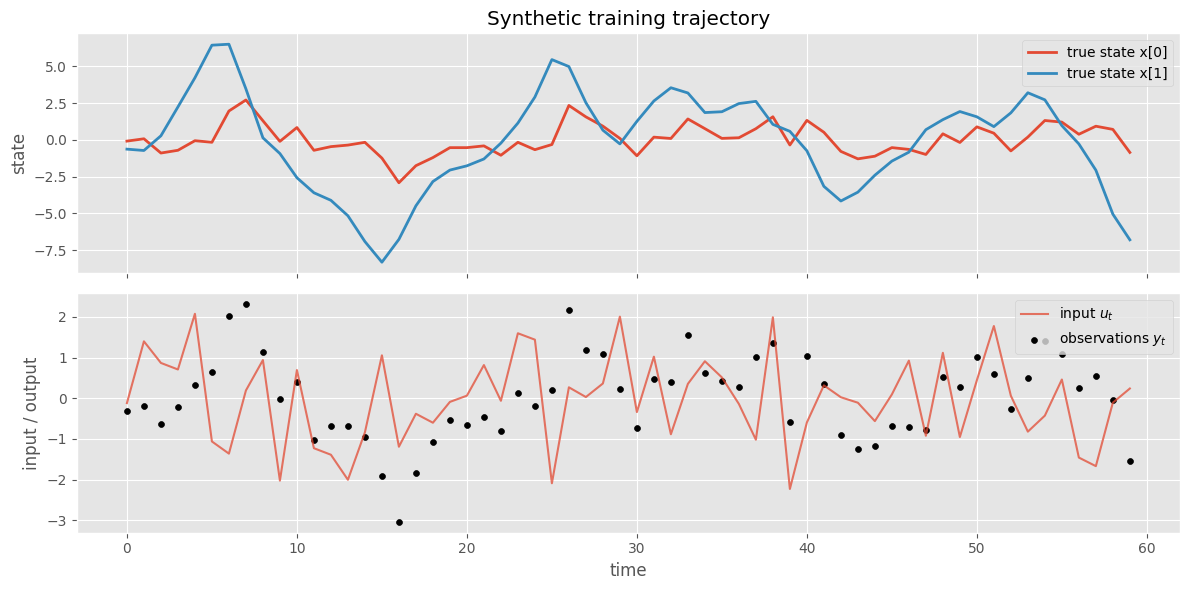

In [15]:
true_dynamics = LTI_discrete(
    A=A_true,
    Q=Q,
    H=C_true,
    R=R,
    B=B_true,
    D=D_true,
    initial_mean=initial_mean,
    initial_cov=initial_cov,
)

def true_system(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None, predict_times=None):
    return dsx.sample(
        "f",
        true_dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
    )

with DiscreteTimeSimulator():
    synthetic = Predictive(
        true_system,
        num_samples=1,
        exclude_deterministic=False,
    )(
        keys["simulate"],
        predict_times=obs_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

true_states = synthetic["f_states"][0, 0]
obs_values = synthetic["f_observations"][0, 0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(obs_times, true_states[:, 0], label="true state x[0]", linewidth=2)
axes[0].plot(obs_times, true_states[:, 1], label="true state x[1]", linewidth=2)
axes[0].legend(loc="upper right")
axes[0].set_ylabel("state")
axes[0].set_title("Synthetic training trajectory")

axes[1].plot(obs_times, ctrl_values[:, 0], label="input $u_t$", alpha=0.75)
axes[1].scatter(obs_times, obs_values[:, 0], label="observations $y_t$", s=18, color="black")
axes[1].legend(loc="upper right")
axes[1].set_ylabel("input / output")
axes[1].set_xlabel("time")
plt.tight_layout()


In [16]:
data_kwargs = dict(
    obs_times=obs_times,
    obs_values=obs_values,
    ctrl_times=ctrl_times,
    ctrl_values=ctrl_values,
)

standard_mcmc = run_nuts(
    conditioned_standard_model,
    keys["standard_nuts"],
    standard_warmup,
    standard_samples,
    **data_kwargs,
)
posterior_samples = standard_mcmc.get_samples()
A_samples, B_samples, C_samples, D_samples = samples_to_abcd(posterior_samples)

A_mean = A_samples.mean(axis=0)
B_mean = B_samples.mean(axis=0)
C_mean = C_samples.mean(axis=0)
D_mean = D_samples.mean(axis=0)

print("Posterior mean A =\n", A_mean)
print("Posterior mean B =\n", B_mean)
print("Posterior mean C =\n", C_mean)
print("Posterior mean D =\n", D_mean)


sample: 100%|██████████| 7000/7000 [19:55<00:00,  5.85it/s, 39 steps of size 1.09e-02. acc. prob=0.67]    


Posterior mean A =
 [[ 0.70028219  0.82934625]
 [-0.79023518  0.69032258]]
Posterior mean B =
 [[ 0.09337586]
 [-0.04999662]]
Posterior mean C =
 [[-0.05544326 -0.07269596]]
Posterior mean D =
 [[0.]]


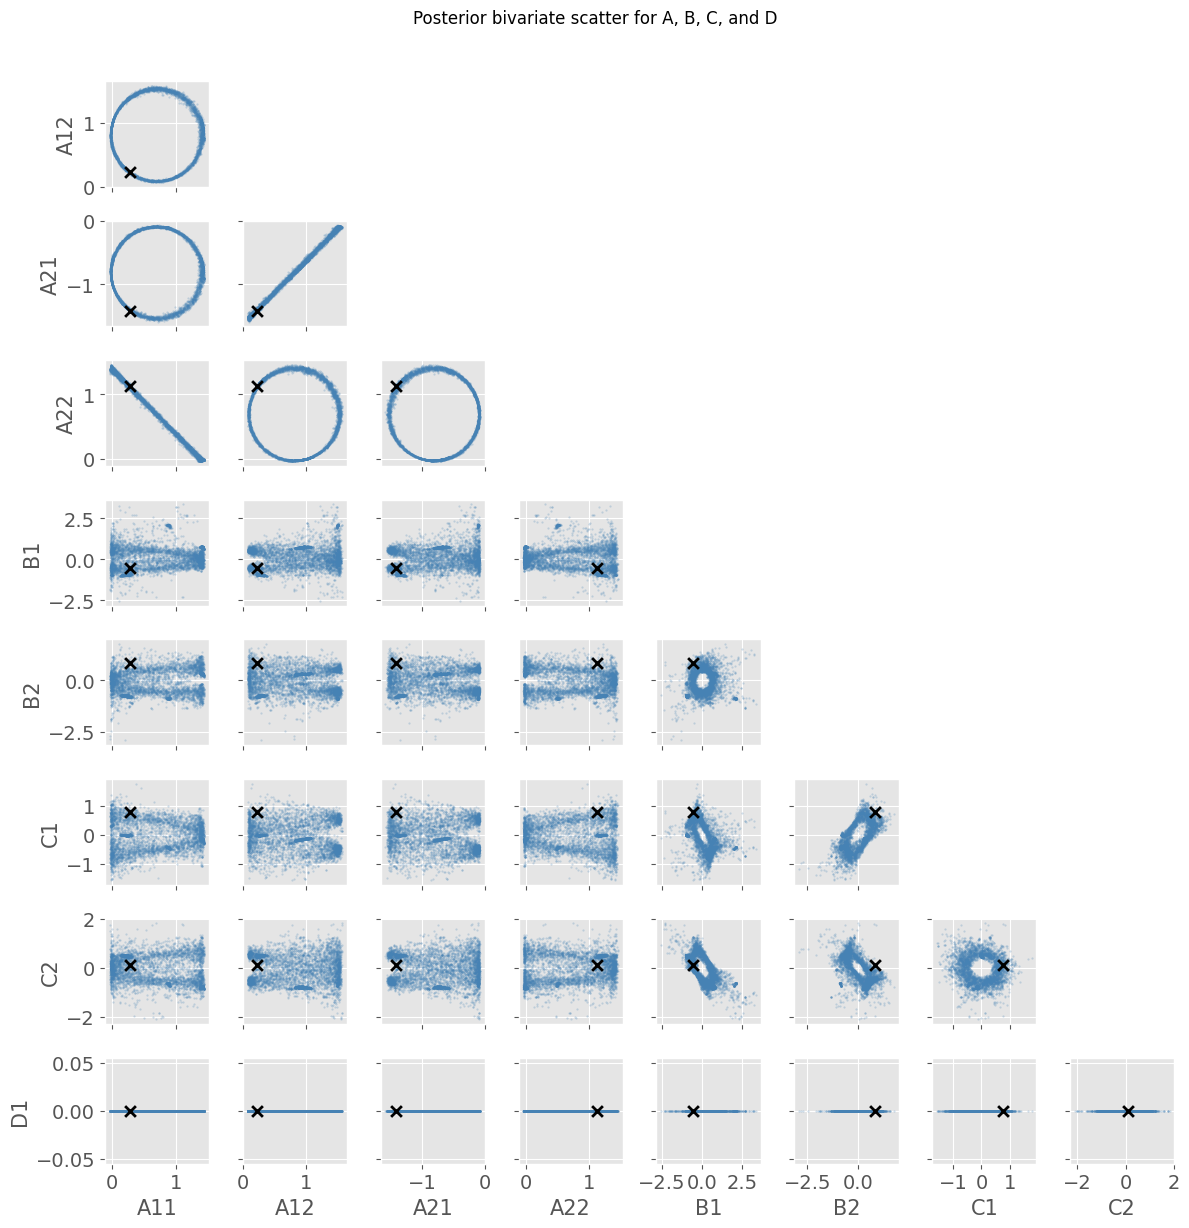

In [17]:
plot_abcd_posteriors(
    A_samples,
    B_samples,
    C_samples,
    D_samples,
    np.asarray(A_true),
    np.asarray(B_true),
    np.asarray(C_true),
    np.asarray(D_true),
)
plt.show()
